In [25]:
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

In [3]:
def p(z):
    return np.exp(-(z**2) / 2) * sigmoid(20 * z + 4)

In [21]:
def q(z):
    return -p(z)

In [32]:
x = np.linspace(-4, 4, 1000)
y = p(x)

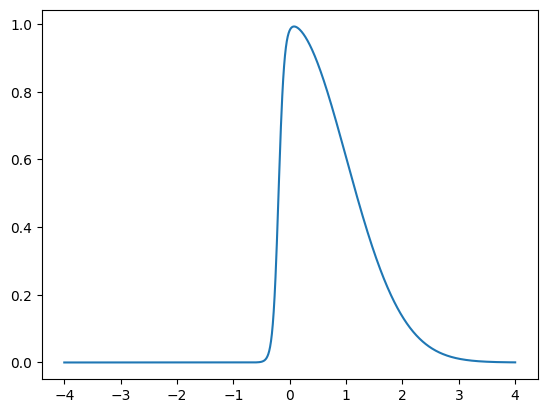

In [33]:
fig, ax = plt.subplots()
ax.plot(x, y)

In [34]:
w_0 = 0.
solution = scipy.optimize.minimize(q, w_0, method='BFGS')
w_map = solution.x
hessian = np.linalg.inv(solution.hess_inv)

In [35]:
w_map

array([0.07748021])

In [36]:
hessian

array([[2.54524915]])

In [50]:
rv = norm(loc=w_map, scale=-hessian)

In [55]:
foo =norm.pdf(x,w_map, -hessian)

In [56]:
ax.plot(x, foo[0], 'k-', lw=2, label='frozen pdf')

In [57]:
ax

<Axes: >

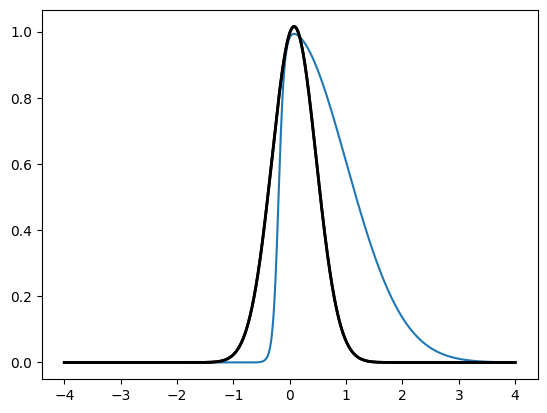

In [58]:
fig

In [59]:
def laplace_approx(w, w_map, H):
    detH =  np.linalg.det(H)
    constant = np.sqrt(detH)/(2*np.pi)**(2.0/2.0)
    density = np.exp(-0.5 * (w-w_map).dot(H).dot(w-w_map))
    return constant * density

In [73]:
z = [laplace_approx(i, w_map, -hessian) for i in x]

/var/folders/9n/xdwvnh2n0p98mf9514dnj_br0000gn/T/ipykernel_81559/2286167828.py:3: RuntimeWarning: invalid value encountered in sqrt
  constant = np.sqrt(detH)/(2*np.pi)**(2.0/2.0)


In [74]:
ax.plot(x, z, 'k-', lw=2, label='frozen pdf')

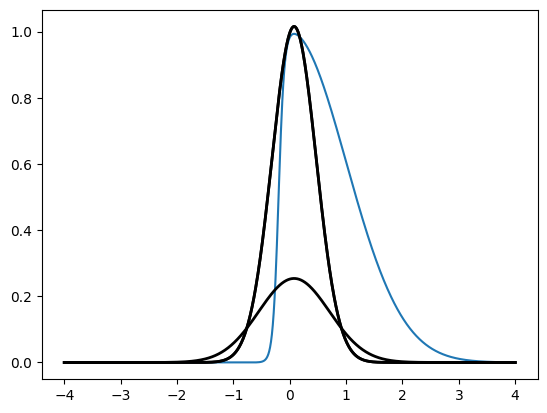

In [75]:
fig